# 02 — Bias Analysis

**NovaCred Credit Application Governance | DEGO 2606**

**Author:** Justus Nau (Data Scientist)

---

## Objectives

Detect bias and fairness issues in NovaCred's historical credit decisions:

| Analysis | Description |
|----------|-------------|
| Disparate Impact | Gender-based approval rate disparity (four-fifths rule) |
| Proxy Discrimination | Non-protected attributes correlating with protected characteristics |
| Age-Based Patterns | Approval and interest rate patterns across age groups |
| Interaction Effects | Combined effects of multiple protected attributes |

---

## Sections

0. Setup & Data Loading
1. Disparate Impact Analysis (Gender)
2. Age-Based Bias Patterns
3. Proxy Discrimination Analysis
4. Interaction Effects
5. Summary & Fairness Recommendations

---
## Section 0 — Setup & Data Loading

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd

# Resolve project root from notebooks/ directory
project_root = Path.cwd().resolve().parent
data_path = project_root / "data" / "clean_credit_applications.csv"

# Load cleaned dataset
df = pd.read_csv(data_path)

# Quick sanity checks
print(f"Loaded: {data_path}")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print("\nColumns:")
print(df.columns.tolist())

display(df.head())

Loaded: /Users/justus/Desktop/Data Governance Team Project/dego-project-team5/data/clean_credit_applications.csv
Shape: 502 rows × 16 columns

Columns:
['_id', 'gender', 'date_of_birth', 'zip_code', 'annual_income', 'credit_history_months', 'debt_to_income', 'savings_balance', 'loan_approved', 'interest_rate', 'approved_amount', 'rejection_reason', 'loan_purpose', 'notes', 'processing_timestamp', 'total_flags']


,_id,gender,date_of_birth,zip_code,annual_income,credit_history_months,debt_to_income,savings_balance,loan_approved,interest_rate,approved_amount,rejection_reason,loan_purpose,notes,processing_timestamp,total_flags
0,app_200,Male,2001-03-09,10036.0,73000.0,23,0.20,31212,False,NaN,NaN,algorithm_risk_score,NaN,NaN,2024-01-15T00:00:00Z,0
1,app_037,Male,1992-03-31,10032.0,78000.0,51,0.18,17915,False,NaN,NaN,algorithm_risk_score,NaN,NaN,NaN,1
2,app_215,Male,1989-10-24,10075.0,61000.0,41,0.21,37909,True,3.7,59000.0,NaN,vacation,NaN,NaN,0
3,app_024,Male,1983-04-25,10077.0,103000.0,70,0.35,0,True,4.3,34000.0,NaN,NaN,NaN,NaN,0
4,app_184,Male,1999-05-21,10080.0,57000.0,14,0.23,31763,False,NaN,NaN,algorithm_risk_score,NaN,NaN,2024-01-15T00:00:00Z,1


---
## Section 1 — Disparate Impact Analysis (Gender)

In [3]:
# Approval rate by gender
gender_rates = (
    df.dropna(subset=['gender', 'loan_approved'])
      .groupby('gender')['loan_approved']
      .mean()
      .sort_values(ascending=False)
      .rename('approval_rate')
)

gender_summary = (gender_rates * 100).round(2).to_frame('approval_rate_pct')
print('Approval rate by gender (%):')
print(gender_summary.to_string())

Approval rate by gender (%):
        approval_rate_pct
gender                   
Male                65.73
Female              50.60


In [4]:
# Disparate Impact (DI) ratio and four-fifths rule interpretation
privileged_gender = gender_rates.idxmax()
unprivileged_gender = gender_rates.idxmin()

approval_privileged = gender_rates.loc[privileged_gender]
approval_unprivileged = gender_rates.loc[unprivileged_gender]

di_ratio = approval_unprivileged / approval_privileged

print(f'Privileged group (higher approval rate): {privileged_gender} ({approval_privileged:.4f})')
print(f'Unprivileged group (lower approval rate): {unprivileged_gender} ({approval_unprivileged:.4f})')
print(f'\nDisparate Impact Ratio (DI) = {di_ratio:.4f}')

threshold = 0.80
if di_ratio < threshold:
    print('Interpretation: DI < 0.80 → potential disparate impact (four-fifths rule violated).')
else:
    print('Interpretation: DI >= 0.80 → no disparate impact flagged by the four-fifths rule.')

Privileged group (higher approval rate): Male (0.6573)
Unprivileged group (lower approval rate): Female (0.5060)

Disparate Impact Ratio (DI) = 0.7698
Interpretation: DI < 0.80 → potential disparate impact (four-fifths rule violated).


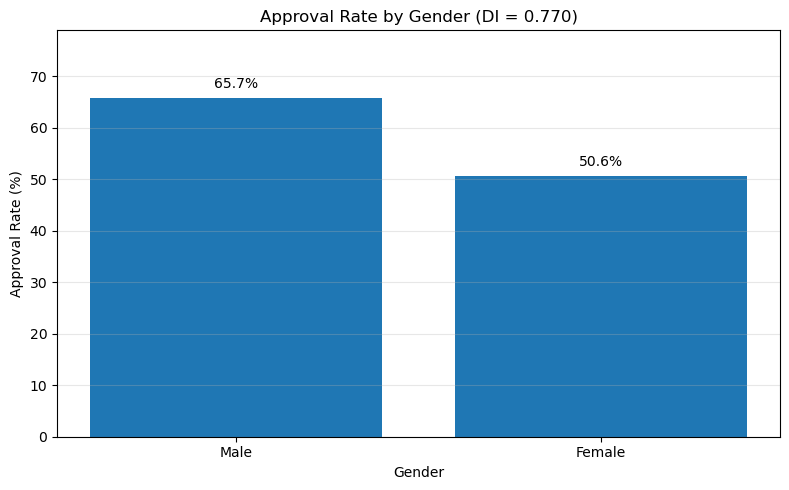

In [8]:
# Bar chart of approval rates by gender with DI annotation
import matplotlib.pyplot as plt

plot_df = gender_rates.sort_values(ascending=False).mul(100).reset_index()
plot_df.columns = ['gender', 'approval_rate_pct']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(plot_df['gender'], plot_df['approval_rate_pct'])

for bar in bars:
    value = bar.get_height()
    ax.annotate(
        f'{value:.1f}%',
        xy=(bar.get_x() + bar.get_width() / 2, value),
        xytext=(0, 5),
        textcoords='offset points',
        ha='center',
        va='bottom'
    )

ax.set_title(f'Approval Rate by Gender (DI = {di_ratio:.3f})')
ax.set_xlabel('Gender')
ax.set_ylabel('Approval Rate (%)')
ax.set_ylim(0, max(plot_df['approval_rate_pct']) * 1.2)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/bias_approval_rate_by_gender.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 2 — Age-Based Bias Patterns

In [9]:
# Derive age from date_of_birth and bin into age groups
analysis_df = df.copy()
analysis_df['date_of_birth'] = pd.to_datetime(analysis_df['date_of_birth'], errors='coerce')
analysis_df['age'] = ((pd.Timestamp.today() - analysis_df['date_of_birth']).dt.days / 365.25).round(1)

valid_age_df = analysis_df[analysis_df['age'].between(18, 100, inclusive='both')].copy()

age_bins = [18, 25, 35, 45, 55, 65, 101]
age_labels = ['18–24', '25–34', '35–44', '45–54', '55–64', '65+']

valid_age_df['age_group'] = pd.cut(
    valid_age_df['age'],
    bins=age_bins,
    labels=age_labels,
    right=False
)

print(f"Records with valid age: {len(valid_age_df)} / {len(df)}")
print(valid_age_df[['date_of_birth', 'age', 'age_group']].head().to_string(index=False))

Records with valid age: 396 / 502
date_of_birth  age age_group
   2001-03-09 25.0     25–34
   1992-03-31 33.9     25–34
   1989-10-24 36.4     35–44
   1983-04-25 42.9     35–44
   1999-05-21 26.8     25–34


In [10]:
# Compare approval rates across age groups
age_approval = (
    valid_age_df.groupby('age_group', observed=False)['loan_approved']
    .agg(records='count', approval_rate='mean')
    .reset_index()
    .sort_values('age_group')
)
age_approval['approval_rate_pct'] = (age_approval['approval_rate'] * 100).round(2)

print('Approval patterns by age group:')
print(age_approval[['age_group', 'records', 'approval_rate_pct']].to_string(index=False))

Approval patterns by age group:
age_group  records  approval_rate_pct
    18–24        9              55.56
    25–34      120              40.83
    35–44      141              65.25
    45–54       72              63.89
    55–64       44              61.36
      65+       10              50.00


In [11]:
# Check interest rates by age group (approved applications only)
approved_age_df = valid_age_df[valid_age_df['loan_approved'] == True].copy()

age_interest = (
    approved_age_df.groupby('age_group', observed=False)['interest_rate']
    .agg(approved_records='count', avg_interest_rate='mean')
    .reset_index()
    .sort_values('age_group')
)
age_interest['avg_interest_rate'] = age_interest['avg_interest_rate'].round(2)

print('Interest-rate patterns among approved applications:')
print(age_interest.to_string(index=False))

Interest-rate patterns among approved applications:
age_group  approved_records  avg_interest_rate
    18–24                 5               4.56
    25–34                49               4.43
    35–44                92               4.49
    45–54                46               4.69
    55–64                27               4.57
      65+                 5               5.02


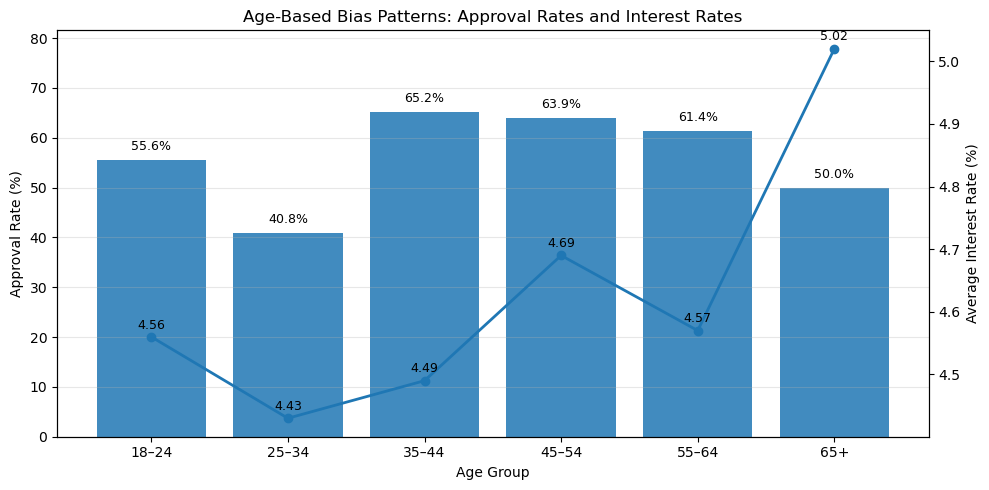

In [12]:
# Compact visualization: approval rate (bar) + avg interest rate (line) by age group
viz_df = age_approval[['age_group', 'approval_rate_pct']].merge(
    age_interest[['age_group', 'avg_interest_rate']],
    on='age_group',
    how='left'
)

fig, ax1 = plt.subplots(figsize=(10, 5))

bars = ax1.bar(viz_df['age_group'].astype(str), viz_df['approval_rate_pct'], alpha=0.85)
ax1.set_xlabel('Age Group')
ax1.set_ylabel('Approval Rate (%)')
ax1.set_ylim(0, max(viz_df['approval_rate_pct']) * 1.25)
ax1.grid(axis='y', alpha=0.3)

for bar in bars:
    value = bar.get_height()
    ax1.annotate(
        f'{value:.1f}%',
        xy=(bar.get_x() + bar.get_width() / 2, value),
        xytext=(0, 5),
        textcoords='offset points',
        ha='center',
        va='bottom',
        fontsize=9
    )

ax2 = ax1.twinx()
ax2.plot(viz_df['age_group'].astype(str), viz_df['avg_interest_rate'], marker='o', linewidth=2)
ax2.set_ylabel('Average Interest Rate (%)')

for x, y in zip(viz_df['age_group'].astype(str), viz_df['avg_interest_rate']):
    if pd.notna(y):
        ax2.annotate(f'{y:.2f}', (x, y), textcoords='offset points', xytext=(0, 6), ha='center', fontsize=9)

plt.title('Age-Based Bias Patterns: Approval Rates and Interest Rates')
plt.tight_layout()
plt.savefig('../reports/bias_age_approval_interest_combo.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 3 — Proxy Discrimination Analysis

In [13]:
# Setup helpers and proxy-ready features
import json

proxy_df = analysis_df.copy()
proxy_df = proxy_df.dropna(subset=['zip_code', 'gender', 'loan_approved'])

proxy_df['zip_code_num'] = pd.to_numeric(proxy_df['zip_code'], errors='coerce')
proxy_df = proxy_df.dropna(subset=['zip_code_num'])
proxy_df['zip_prefix'] = proxy_df['zip_code_num'].astype(int).astype(str).str.zfill(5).str[:3]


def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    if ct.empty:
        return np.nan
    observed = ct.to_numpy()
    n = observed.sum()
    if n == 0:
        return np.nan

    row_sums = observed.sum(axis=1, keepdims=True)
    col_sums = observed.sum(axis=0, keepdims=True)
    expected = row_sums @ col_sums / n

    with np.errstate(divide='ignore', invalid='ignore'):
        chi2 = np.nansum((observed - expected) ** 2 / expected)

    r, c = observed.shape
    if min(r, c) <= 1:
        return np.nan

    return np.sqrt((chi2 / n) / (min(r - 1, c - 1)))


def correlation_ratio(categories, measurements):
    frame = pd.DataFrame({'cat': categories, 'val': measurements}).dropna()
    if frame.empty:
        return np.nan

    group_means = frame.groupby('cat')['val'].mean()
    group_counts = frame.groupby('cat')['val'].count()

    grand_mean = frame['val'].mean()
    ss_between = ((group_means - grand_mean) ** 2 * group_counts).sum()
    ss_total = ((frame['val'] - grand_mean) ** 2).sum()

    if ss_total == 0:
        return np.nan

    return np.sqrt(ss_between / ss_total)

print(f'Proxy analysis base records: {len(proxy_df)}')
print(f'Unique ZIP prefixes: {proxy_df["zip_prefix"].nunique()}')

Proxy analysis base records: 499
Unique ZIP prefixes: 3


In [14]:
# Correlate ZIP code with protected attributes (gender, age)
zip_gender_ct = pd.crosstab(proxy_df['zip_prefix'], proxy_df['gender'])
zip_gender_top = zip_gender_ct.sum(axis=1).sort_values(ascending=False).head(10).index

print('Top ZIP prefixes by volume with gender counts:')
print(zip_gender_ct.loc[zip_gender_top].to_string())

zip_gender_assoc = cramers_v(proxy_df['zip_prefix'], proxy_df['gender'])
print(f"\nCramer's V (ZIP prefix vs gender): {zip_gender_assoc:.3f}")

zip_age_means = (
    proxy_df.groupby('zip_prefix')['age']
    .agg(records='count', avg_age='mean')
    .sort_values('records', ascending=False)
    .head(10)
)
zip_age_means['avg_age'] = zip_age_means['avg_age'].round(2)

print('\nTop ZIP prefixes with average age:')
print(zip_age_means.to_string())

zip_age_assoc = correlation_ratio(proxy_df['zip_prefix'], proxy_df['age'])
print(f"\nCorrelation ratio eta (ZIP prefix -> age): {zip_age_assoc:.3f}")

Top ZIP prefixes by volume with gender counts:
gender      Female  Male
zip_prefix              
100             28   223
902            215    15
300              8    10

Cramer's V (ZIP prefix vs gender): 0.808

Top ZIP prefixes with average age:
            records  avg_age
zip_prefix                  
100             194    40.75
902             184    41.44
300              17    40.89

Correlation ratio eta (ZIP prefix -> age): 0.031


In [15]:
# Check whether ZIP code predicts approval independently (incremental model test)
model_df = proxy_df.dropna(subset=['annual_income', 'credit_history_months', 'debt_to_income', 'savings_balance', 'age']).copy()
model_df['approval_flag'] = model_df['loan_approved'].astype(int)

base_features = ['annual_income', 'credit_history_months', 'debt_to_income', 'savings_balance', 'age']

X_base = pd.get_dummies(model_df[base_features + ['gender']], drop_first=True)
X_zip = pd.get_dummies(model_df[base_features + ['gender', 'zip_prefix']], drop_first=True)
y = model_df['approval_flag']

try:
    from sklearn.linear_model import LogisticRegression
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import roc_auc_score

    Xb_train, Xb_test, y_train, y_test = train_test_split(X_base, y, test_size=0.3, random_state=42, stratify=y)
    Xz_train, Xz_test, _, _ = train_test_split(X_zip, y, test_size=0.3, random_state=42, stratify=y)

    base_model = LogisticRegression(max_iter=2000)
    zip_model = LogisticRegression(max_iter=2000)

    base_model.fit(Xb_train, y_train)
    zip_model.fit(Xz_train, y_train)

    auc_base = roc_auc_score(y_test, base_model.predict_proba(Xb_test)[:, 1])
    auc_zip = roc_auc_score(y_test, zip_model.predict_proba(Xz_test)[:, 1])

    print(f'Base model AUC (no ZIP): {auc_base:.3f}')
    print(f'ZIP-augmented model AUC: {auc_zip:.3f}')
    print(f'Delta AUC from adding ZIP: {auc_zip - auc_base:+.3f}')

except Exception as exc:
    zip_approval = (
        model_df.groupby('zip_prefix')['loan_approved']
        .agg(records='count', approval_rate='mean')
        .sort_values('records', ascending=False)
        .head(10)
    )
    zip_approval['approval_rate'] = (zip_approval['approval_rate'] * 100).round(2)

    print('Model-based AUC test skipped (missing dependency/runtime issue).')
    print(f'Reason: {exc}')
    print('\nFallback: top ZIP prefixes and approval rates (%)')
    print(zip_approval.to_string())

Base model AUC (no ZIP): 0.598
ZIP-augmented model AUC: 0.591
Delta AUC from adding ZIP: -0.007


In [16]:
# Investigate spending_behavior categories as potential proxy variables
raw_path = project_root / 'data' / 'raw_credit_applications.json'

with open(raw_path, 'r') as f:
    raw_records = json.load(f)

spend_rows = []
for record in raw_records:
    app_id = record.get('_id')
    spends = record.get('spending_behavior', []) or []

    if not spends:
        spend_rows.append({'_id': app_id, 'top_spend_category': np.nan, 'top_spend_amount': np.nan})
        continue

    spend_df_tmp = pd.DataFrame(spends)
    if {'category', 'amount'}.issubset(spend_df_tmp.columns):
        spend_df_tmp['amount'] = pd.to_numeric(spend_df_tmp['amount'], errors='coerce')
        spend_df_tmp = spend_df_tmp.dropna(subset=['amount'])

        if spend_df_tmp.empty:
            spend_rows.append({'_id': app_id, 'top_spend_category': np.nan, 'top_spend_amount': np.nan})
        else:
            top_row = spend_df_tmp.sort_values('amount', ascending=False).iloc[0]
            spend_rows.append({
                '_id': app_id,
                'top_spend_category': top_row['category'],
                'top_spend_amount': float(top_row['amount'])
            })
    else:
        spend_rows.append({'_id': app_id, 'top_spend_category': np.nan, 'top_spend_amount': np.nan})

spend_proxy = pd.DataFrame(spend_rows)
proxy_spend_df = proxy_df.merge(spend_proxy, on='_id', how='left')

category_stats = (
    proxy_spend_df.dropna(subset=['top_spend_category'])
    .groupby('top_spend_category')['loan_approved']
    .agg(records='count', approval_rate='mean')
    .sort_values('records', ascending=False)
)
category_stats['approval_rate_pct'] = (category_stats['approval_rate'] * 100).round(2)

print('Top spending categories with approval rates (%):')
print(category_stats[['records', 'approval_rate_pct']].head(10).to_string())

cat_gender_assoc = cramers_v(
    proxy_spend_df['top_spend_category'].fillna('Unknown'),
    proxy_spend_df['gender']
)
cat_approval_assoc = cramers_v(
    proxy_spend_df['top_spend_category'].fillna('Unknown'),
    proxy_spend_df['loan_approved']
)

print(f"\nCramer's V (spending category vs gender): {cat_gender_assoc:.3f}")
print(f"Cramer's V (spending category vs approval): {cat_approval_assoc:.3f}")

Top spending categories with approval rates (%):
                    records  approval_rate_pct
top_spend_category                            
Travel                   49              51.02
Utilities                46              54.35
Fitness                  45              60.00
Education                44              59.09
Entertainment            43              58.14
Dining                   42              40.48
Groceries                42              64.29
Insurance                40              75.00
Rent                     39              33.33
Healthcare               37              64.86

Cramer's V (spending category vs gender): 0.159
Cramer's V (spending category vs approval): 0.241
